In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Data yuklash va tozalash ──────────────────────────
df = pd.read_csv(r"C:\Users\MAXMU\Desktop\DASTURLASH\Data\car_prices.csv")
df_clean = df.copy()

year_median = int(df_clean[(df_clean['year'] >= 1990) & (df_clean['year'] <= 2025)]['year'].median())
mileage_median = int(df_clean[(df_clean['mileage_km'] >= 0) & (df_clean['mileage_km'] <= 500000)]['mileage_km'].median())
df_clean.loc[(df_clean['year'] < 1990) | (df_clean['year'] > 2025), 'year'] = year_median
df_clean.loc[(df_clean['mileage_km'] < 0) | (df_clean['mileage_km'] > 500000), 'mileage_km'] = mileage_median

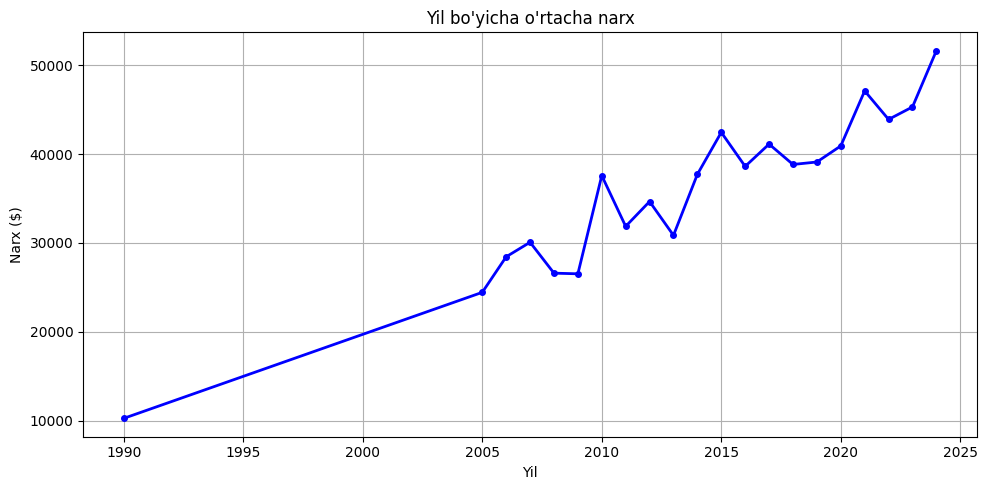

In [2]:
# 1. LINE PLOT — yil bo'yicha o'rtacha narx
year_price = df_clean.groupby('year')['price'].mean()

plt.figure(figsize=(10, 5))
plt.plot(year_price.index, year_price.values, color='blue', linewidth=2, marker='o', markersize=4)
plt.title("Yil bo'yicha o'rtacha narx")
plt.xlabel("Yil")
plt.ylabel("Narx ($)")
plt.grid(True)
plt.tight_layout()
plt.show()





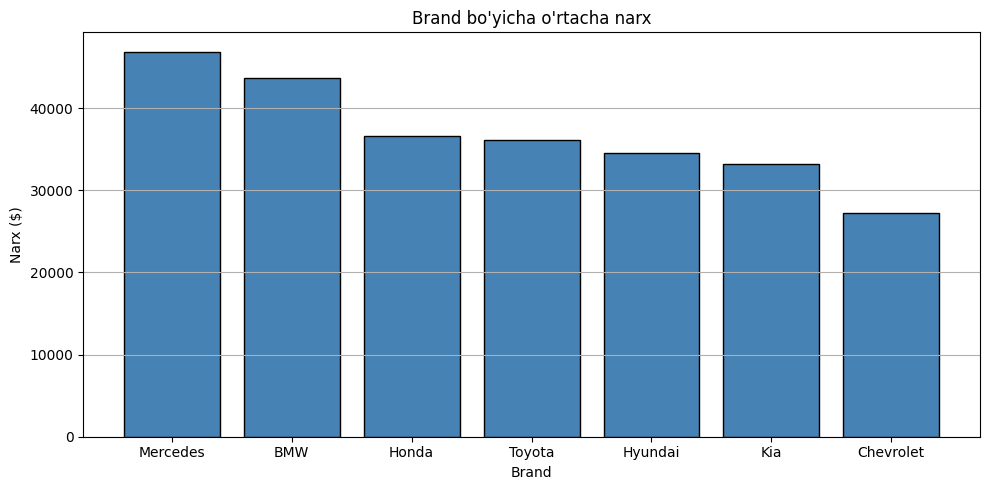

In [3]:
# 2. BAR CHART — brand bo'yicha o'rtacha narx
brand_price = df_clean.groupby('brand')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(brand_price.index, brand_price.values, color='steelblue', edgecolor='black')
plt.title("Brand bo'yicha o'rtacha narx")
plt.xlabel("Brand")
plt.ylabel("Narx ($)")
plt.grid(axis='y')
plt.tight_layout()
plt.show()



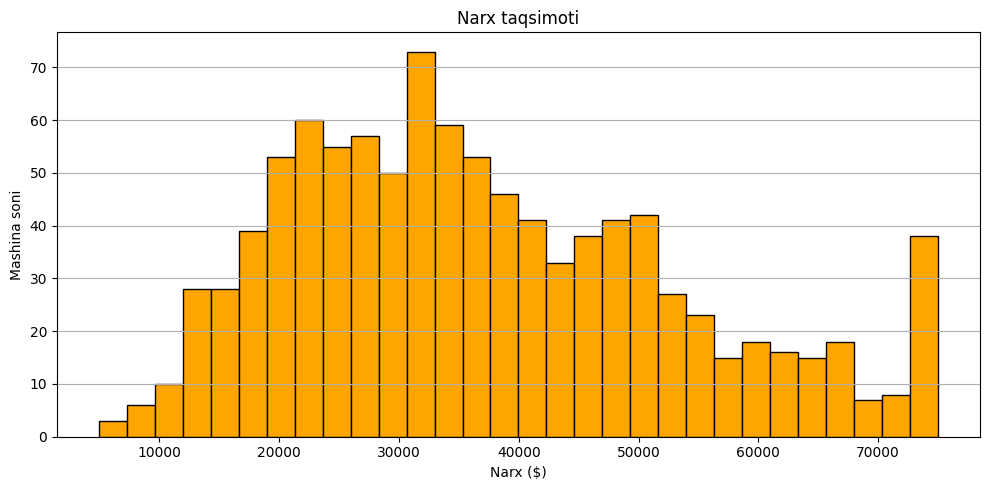

In [4]:

# 3. HISTOGRAM — narx taqsimoti
plt.figure(figsize=(10, 5))
plt.hist(df_clean['price'], bins=30, color='orange', edgecolor='black')
plt.title("Narx taqsimoti")
plt.xlabel("Narx ($)")
plt.ylabel("Mashina soni")
plt.grid(axis='y')
plt.tight_layout()
plt.show()





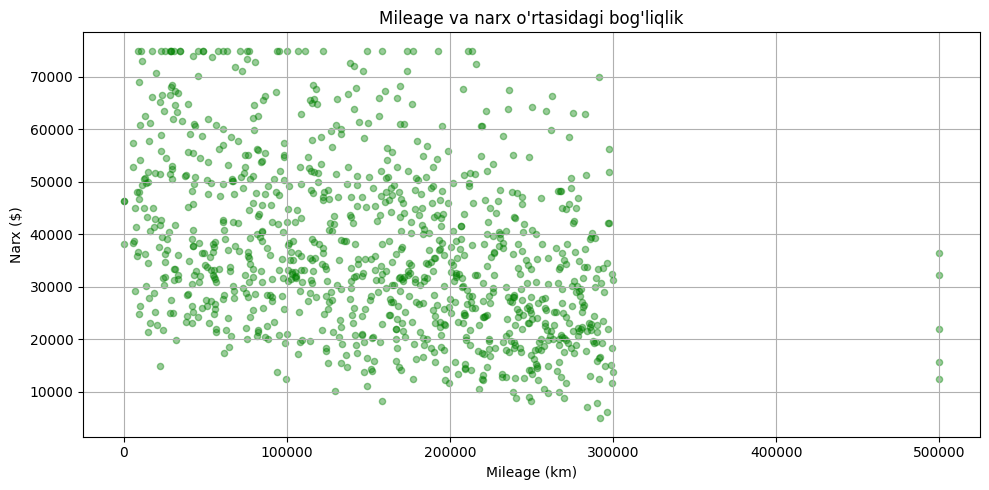

In [5]:
# 4. SCATTER PLOT — mileage vs narx
plt.figure(figsize=(10, 5))
plt.scatter(df_clean['mileage_km'], df_clean['price'], alpha=0.4, color='green', s=20)
plt.title("Mileage va narx o'rtasidagi bog'liqlik")
plt.xlabel("Mileage (km)")
plt.ylabel("Narx ($)")
plt.grid(True)
plt.tight_layout()
plt.show()





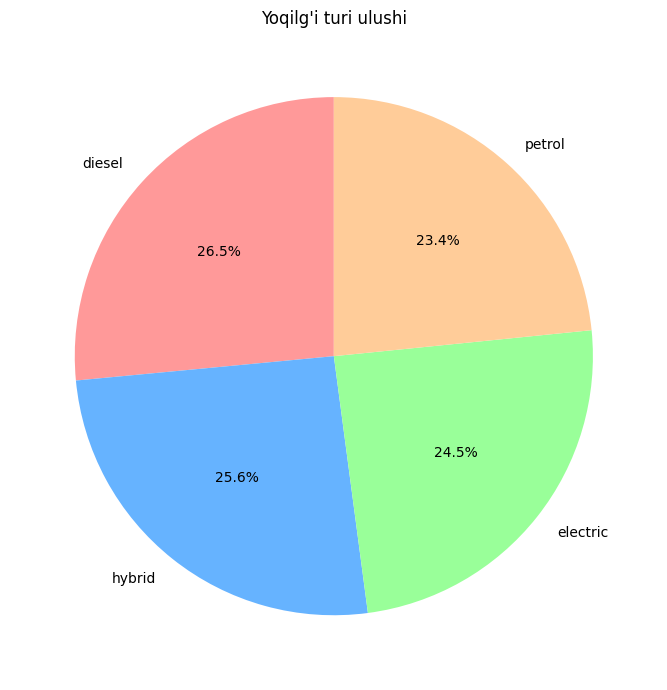

In [6]:
# 5. PIE CHART — yoqilg'i turi ulushi
fuel_counts = df_clean['fuel_type'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(fuel_counts.values, labels=fuel_counts.index,
        autopct='%1.1f%%', startangle=90,
        colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title("Yoqilg'i turi ulushi")
plt.tight_layout()
plt.show()



C:\Users\MAXMU\AppData\Local\Temp\ipykernel_4708\2341373560.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_brand, labels=brands, patch_artist=True)


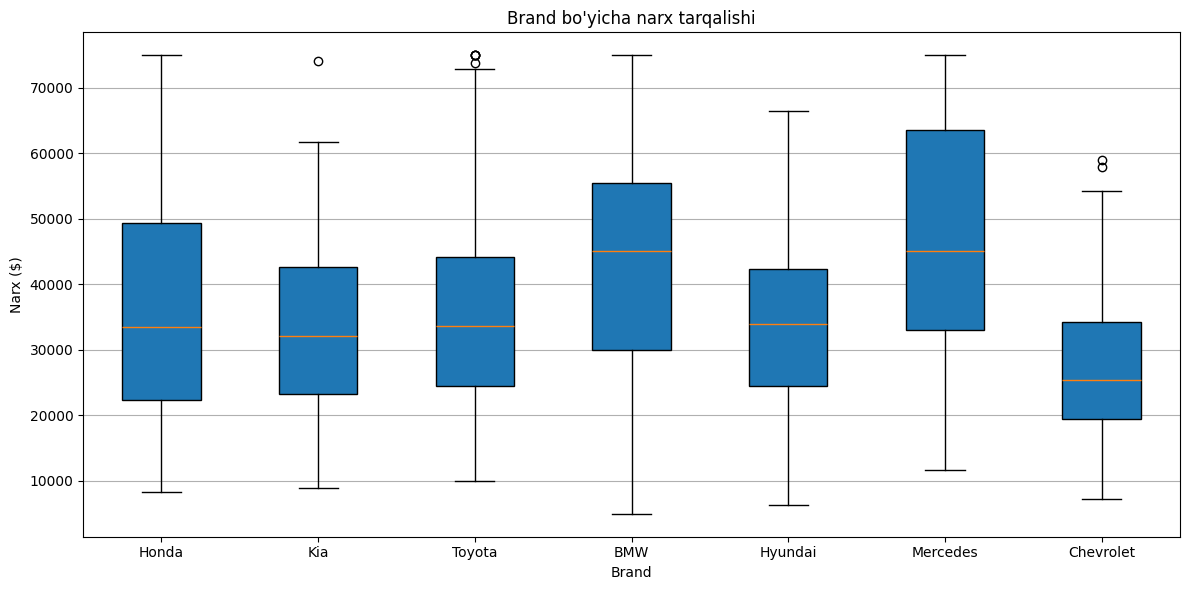

In [7]:


# 6. BOX PLOT — brand bo'yicha narx tarqalishi
brands = df_clean['brand'].unique()
data_by_brand = [df_clean[df_clean['brand'] == b]['price'].values for b in brands]

plt.figure(figsize=(12, 6))
plt.boxplot(data_by_brand, labels=brands, patch_artist=True)
plt.title("Brand bo'yicha narx tarqalishi")
plt.xlabel("Brand")
plt.ylabel("Narx ($)")
plt.grid(axis='y')
plt.tight_layout()
plt.show()



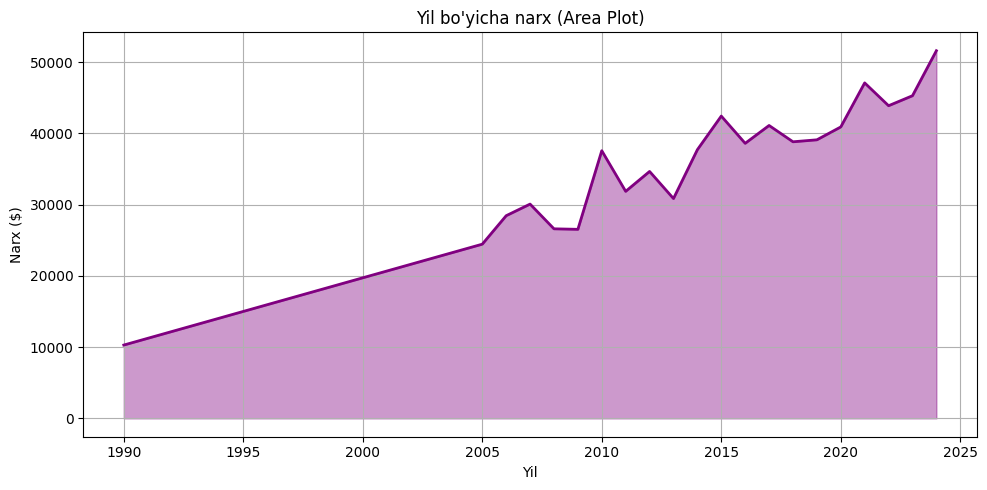

In [8]:

# 7. AREA PLOT — yil bo'yicha o'rtacha narx (to'ldirilgan)
year_price = df_clean.groupby('year')['price'].mean()

plt.figure(figsize=(10, 5))
plt.fill_between(year_price.index, year_price.values, alpha=0.4, color='purple')
plt.plot(year_price.index, year_price.values, color='purple', linewidth=2)
plt.title("Yil bo'yicha narx (Area Plot)")
plt.xlabel("Yil")
plt.ylabel("Narx ($)")
plt.grid(True)
plt.tight_layout()
plt.show()



C:\Users\MAXMU\AppData\Local\Temp\ipykernel_4708\601660435.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='transmission', y='price', palette='muted')


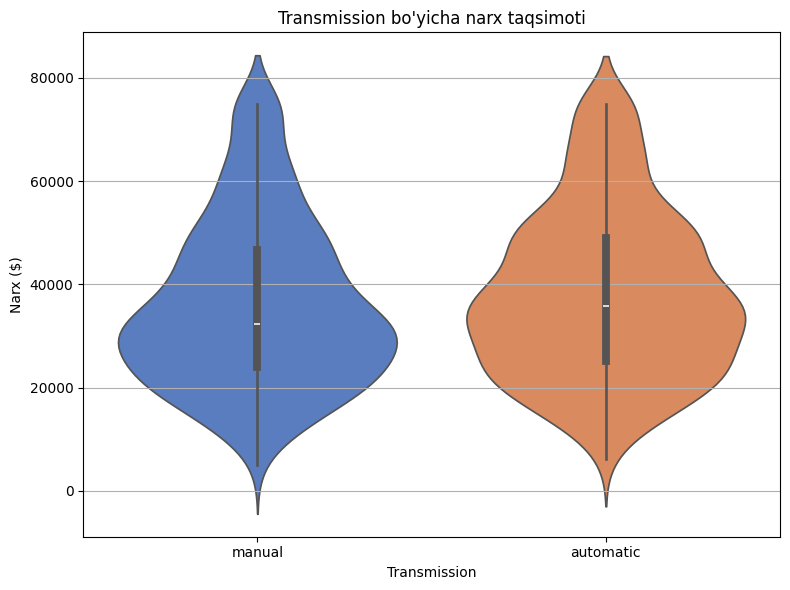

In [9]:
# 8. VIOLIN PLOT — transmission bo'yicha narx
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.violinplot(data=df_clean, x='transmission', y='price', palette='muted')
plt.title("Transmission bo'yicha narx taqsimoti")
plt.xlabel("Transmission")
plt.ylabel("Narx ($)")
plt.grid(axis='y')
plt.tight_layout()
plt.show()




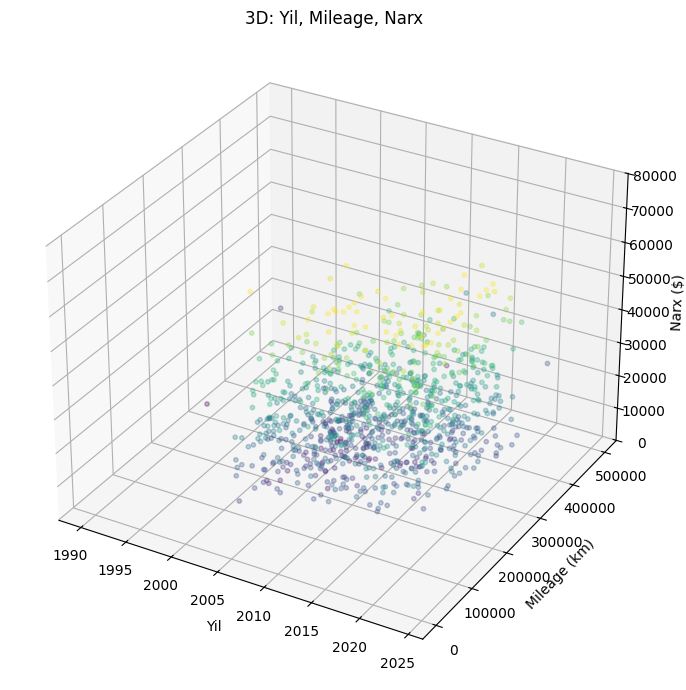

In [10]:
# 9. 3D PLOT — yil, mileage, narx
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df_clean['year'], df_clean['mileage_km'], df_clean['price'],
           alpha=0.3, s=10, c=df_clean['price'], cmap='viridis')

ax.set_title("3D: Yil, Mileage, Narx")
ax.set_xlabel("Yil")
ax.set_ylabel("Mileage (km)")
ax.set_zlabel("Narx ($)")
plt.tight_layout()
plt.show()



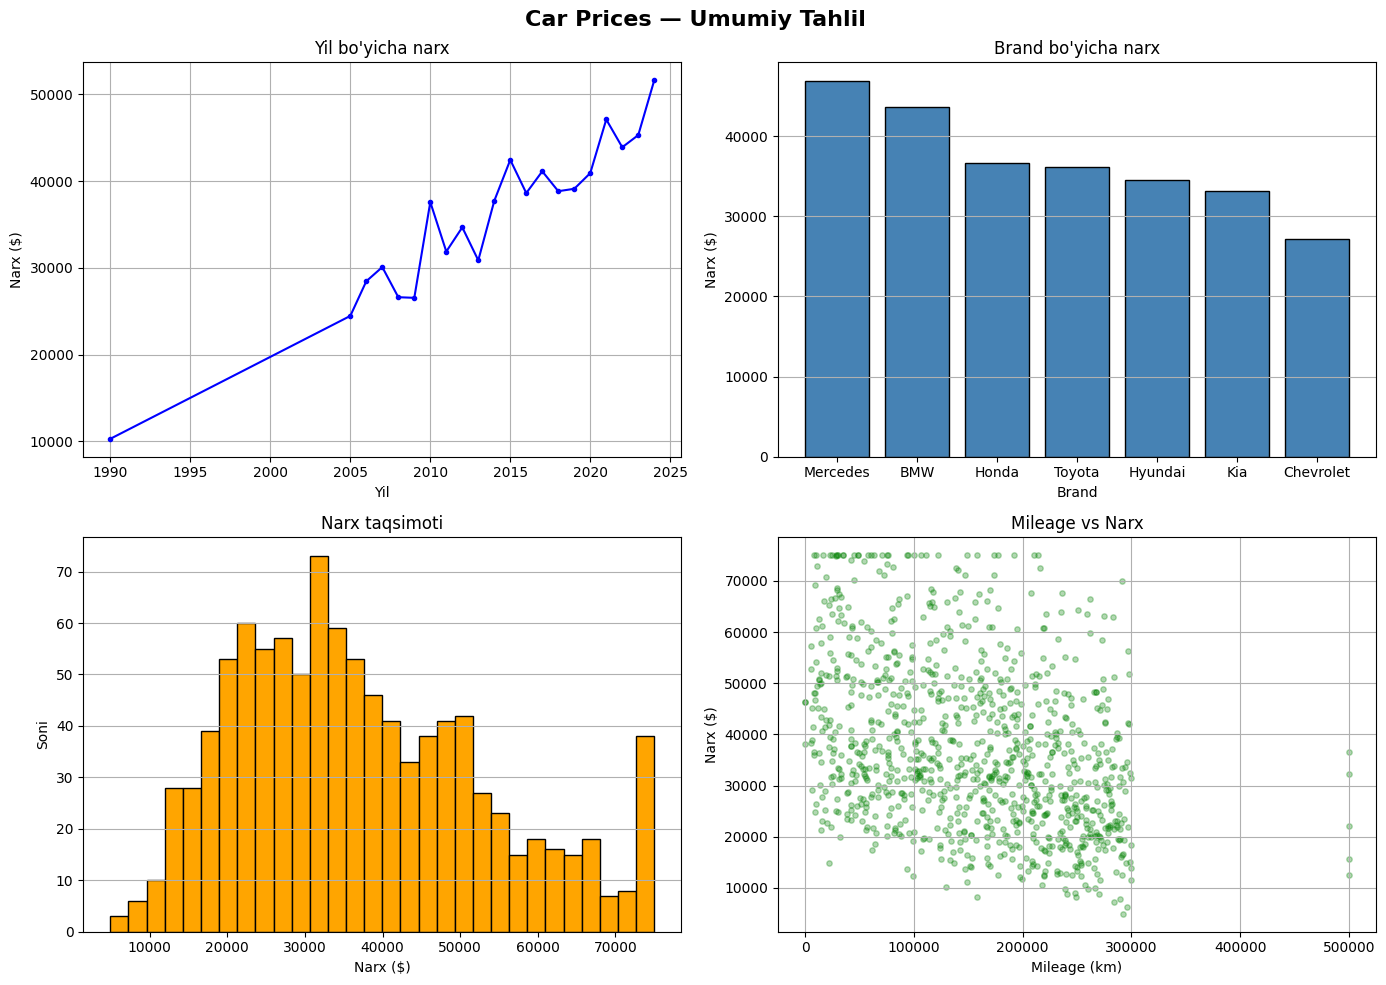

In [11]:
# 10. SUBPLOTS — 4 ta graf bitta oynada
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Car Prices — Umumiy Tahlil", fontsize=16, fontweight='bold')

# a) Line plot
year_price = df_clean.groupby('year')['price'].mean()
axes[0, 0].plot(year_price.index, year_price.values, color='blue', marker='o', markersize=3)
axes[0, 0].set_title("Yil bo'yicha narx")
axes[0, 0].set_xlabel("Yil")
axes[0, 0].set_ylabel("Narx ($)")
axes[0, 0].grid(True)

# b) Bar chart
brand_price = df_clean.groupby('brand')['price'].mean().sort_values(ascending=False)
axes[0, 1].bar(brand_price.index, brand_price.values, color='steelblue', edgecolor='black')
axes[0, 1].set_title("Brand bo'yicha narx")
axes[0, 1].set_xlabel("Brand")
axes[0, 1].set_ylabel("Narx ($)")
axes[0, 1].grid(axis='y')

# c) Histogram
axes[1, 0].hist(df_clean['price'], bins=30, color='orange', edgecolor='black')
axes[1, 0].set_title("Narx taqsimoti")
axes[1, 0].set_xlabel("Narx ($)")
axes[1, 0].set_ylabel("Soni")
axes[1, 0].grid(axis='y')

# d) Scatter plot
axes[1, 1].scatter(df_clean['mileage_km'], df_clean['price'], alpha=0.3, color='green', s=15)
axes[1, 1].set_title("Mileage vs Narx")
axes[1, 1].set_xlabel("Mileage (km)")
axes[1, 1].set_ylabel("Narx ($)")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()